In [2]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Conectar base de datos SQLite

engine = create_engine('sqlite:///modelo_limpio.db', echo=False)
print("Base de datos 'modelo_limpio.db' lista")

Base de datos 'modelo_limpio.db' lista


In [4]:
# Cargar archivos csv desde la carpeta creada
carpeta = 'dataframes_exportados'

# Leer cada uno individualmente
CN_base = pd.read_csv(f'{carpeta}/CN_base.csv')
CN_HCDN = pd.read_csv(f'{carpeta}/CN_HCDN.csv')
CN_HSN = pd.read_csv(f'{carpeta}/CN_HSN.csv')
CN_25_27 = pd.read_csv(f'{carpeta}/CN_25_27.csv')
E_23_PASO = pd.read_csv(f'{carpeta}/E_23_PASO.csv')
E_23_generales = pd.read_csv(f'{carpeta}/E_23_generales.csv')
E_25_HCDN = pd.read_csv(f'{carpeta}/E_25_HCDN.csv')
E_25_HSN = pd.read_csv(f'{carpeta}/E_25_HSN.csv')
barometro = pd.read_csv(f'{carpeta}/barometro.csv')

#### CANTIDAD DIPUTADXS Y SENADORES POR GÉNERO

In [5]:
# Filtrar último período
ultimo_periodo = CN_base[CN_base['composicion'] == CN_base['composicion'].max()]
ultimo_periodo = ultimo_periodo[ultimo_periodo['jurisdiccion'] != 'total pais']

# Diputados
mujeres_dip = ultimo_periodo['cantidad diputadas'].sum()
hombres_dip = ultimo_periodo['diputadxs'].sum() - mujeres_dip

# Senadores
mujeres_sen = ultimo_periodo['cantidad senadoras'].sum()
hombres_sen = ultimo_periodo['senadorxs'].sum() - mujeres_sen

print(f"Honorable Cámara de Diputados de la Nación - Mujeres: {mujeres_dip}, Hombres: {hombres_dip}")
print(f"Honorable Senado de la Nación - Mujeres: {mujeres_sen}, Hombres: {hombres_sen}")

Honorable Cámara de Diputados de la Nación - Mujeres: 106, Hombres: 151
Honorable Senado de la Nación - Mujeres: 33, Hombres: 39


#### CANTIDAD DIPUTADXS Y SENADORES POR EJE IDEOLÓGICO

In [6]:
# DIPUTADOS ACTUALES (2026) POR EJE IDEOLÓGICO

# 1. Filtrar diputados del período actual (2025-2027)
diputados_actuales = CN_HCDN[CN_HCDN['composicion'] == '2025-2027'].copy()

# 2. Unir con barómetro y asignar 6 (Centro) a no clasificados
diputados_actuales = diputados_actuales.merge(barometro, on='bloque', how='left')
diputados_actuales['eje'] = diputados_actuales['eje'].fillna(6)

print(f"Total diputados: {len(diputados_actuales)} (debe ser 257)")

# 3. Por eje ideológico
dip_por_eje = diputados_actuales.groupby('eje').size().reset_index(name='bancas')
dip_por_eje = dip_por_eje.sort_values('eje')

for _, row in dip_por_eje.iterrows():
    eje = row['eje']
    bancas = row['bancas']
    if eje == 1: nombre = "Progresista"
    elif eje == 2: nombre = "Centro-progresista"
    elif eje == 3: nombre = "Centro"
    elif eje == 4: nombre = "Centro-conservador"
    elif eje == 5: nombre = "Conservador"
    else: nombre = "Centro"         # Partidos no_clasificados se suman al eje 'centro'
    print(f"{nombre}: {bancas} bancas ({round(bancas*100/257,1)}%)")

Total diputados: 257 (debe ser 257)
Progresista: 4.0 bancas (1.6%)
Centro-progresista: 93.0 bancas (36.2%)
Centro: 2.0 bancas (0.8%)
Centro-conservador: 12.0 bancas (4.7%)
Conservador: 95.0 bancas (37.0%)
Centro: 51.0 bancas (19.8%)


In [7]:
# SENADORES ACTUALES (2026) POR EJE IDEOLÓGICO

# 1. Filtrar senadores del período actual (2025-2027)
senadores_actuales = CN_HSN[CN_HSN['composicion'] == '2025-2027'].copy()

# 2. Unir con barómetro y asignar 6 (Centro) a no clasificados
senadores_actuales = senadores_actuales.merge(barometro, on='bloque', how='left')
senadores_actuales['eje'] = senadores_actuales['eje'].fillna(6)

print(f"Total senadores: {len(senadores_actuales)} (debe ser 72)")

# 3. Por eje ideológico
sen_por_eje = senadores_actuales.groupby('eje').size().reset_index(name='bancas')
sen_por_eje = sen_por_eje.sort_values('eje')

for _, row in sen_por_eje.iterrows():
    eje = row['eje']
    bancas = row['bancas']
    if eje == 1: nombre = "Progresista"
    elif eje == 2: nombre = "Centro-progresista"
    elif eje == 3: nombre = "Centro"
    elif eje == 4: nombre = "Centro-conservador"
    elif eje == 5: nombre = "Conservador"
    else: nombre = "Centro"         # Partidos no clasificados se suman al eje 'centro'
    print(f"{nombre}: {bancas} bancas ({round(bancas*100/72,1)}%)")

Total senadores: 72 (debe ser 72)
Centro-conservador: 3.0 bancas (4.2%)
Conservador: 20.0 bancas (27.8%)
Centro: 49.0 bancas (68.1%)


#### COMPOSICIÓN DE GÉNERO POR EJE IDEOLÓGICO - DIPUTADOS (2025-2027)

In [8]:
# 1. Filtrar diputados de CN_25_27
diputados_actuales = CN_25_27[CN_25_27['camara'] == 'diputados'].copy()
# 2. Unir con barómetro para eje ideológico
diputados_actuales = diputados_actuales.merge(barometro, left_on='bloque', right_on='bloque', how='left')
diputados_actuales['eje'] = diputados_actuales['eje'].fillna('no_confirmado')
# 3. Resultados por género y eje
resultado = diputados_actuales.groupby(['genero', 'eje']).size().reset_index(name='bancas')
resultado = resultado.sort_values(['eje', 'genero'])

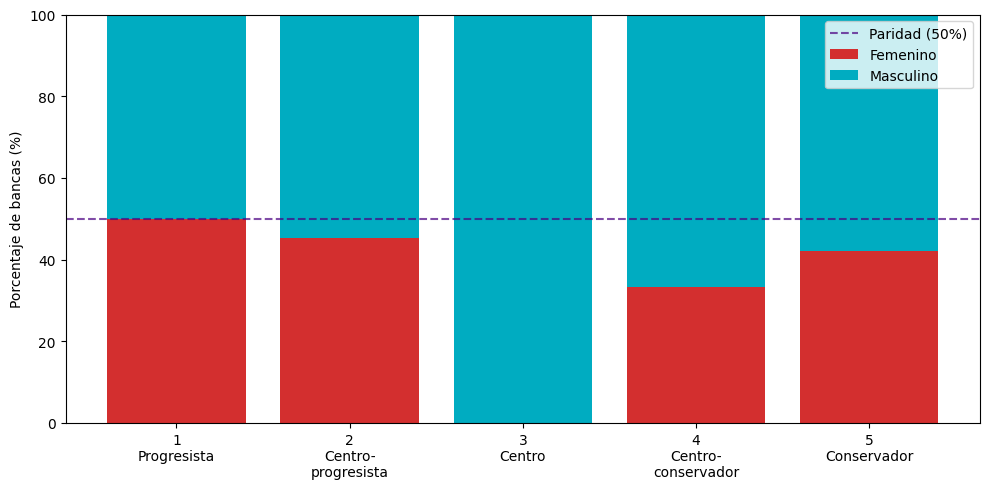

In [9]:
# Filtrar solo ejes clasificados (1, 2, 3, 4, 5)
resultado_clasificados = resultado[resultado['eje'].isin([1, 2, 3, 4, 5])].copy()

# Calcular porcentajes por eje
totales_por_eje = resultado_clasificados.groupby('eje')['bancas'].transform('sum')
resultado_clasificados['porcentaje'] = (resultado_clasificados['bancas'] / totales_por_eje) * 100

# Pivot
pivot = resultado_clasificados.pivot(index='eje', columns='genero', values='porcentaje').fillna(0)
pivot = pivot.reindex([1, 2, 3, 4, 5])  # Ordenar ejes

# Visual
fig, ax = plt.subplots(figsize=(10, 5))

# Barras apiladas
ax.bar(pivot.index, pivot['femenino'], label='Femenino', color='#D32F2F')
ax.bar(pivot.index, pivot['masculino'], bottom=pivot['femenino'], label='Masculino', color='#00ACC1')

# Línea paridad
ax.axhline(50, color='#4B0082', linestyle='--', alpha=0.7, label='Paridad (50%)')

# Etiquetas
ax.set_ylabel('Porcentaje de bancas (%)')
ax.legend()
ax.set_ylim(0, 100)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1\nProgresista', '2\nCentro-\nprogresista', '3\nCentro', '4\nCentro-\nconservador', '5\nConservador'])

plt.tight_layout()
plt.show()

In [42]:
# Calcular porcentajes por eje ideológico

# Filtrar solo ejes clasificados
resultado_clasificados = resultado[resultado['eje'].isin([1, 2, 3, 4, 5])].copy()

# Calcular totales por eje
for eje in [1, 2, 3, 4, 5]:
    datos_eje = resultado_clasificados[resultado_clasificados['eje'] == eje]
    total_eje = datos_eje['bancas'].sum()
    
    if total_eje > 0:
        mujeres = datos_eje[datos_eje['genero'] == 'femenino']['bancas'].sum()
        hombres = datos_eje[datos_eje['genero'] == 'masculino']['bancas'].sum()
        
        pct_mujeres = round((mujeres / total_eje) * 100, 1)
        pct_hombres = round((hombres / total_eje) * 100, 1)
        
        # Nombre del eje
        if eje == 1: nombre = "Progresista"
        elif eje == 2: nombre = "Centro-progresista"
        elif eje == 3: nombre = "Centro"
        elif eje == 4: nombre = "Centro-conservador"
        elif eje == 5: nombre = "Conservador"
        
        print(f"\n Eje {eje} ({nombre}): Total {total_eje} bancas")
        print(f"   Mujeres: {mujeres} ({pct_mujeres}%)")
        print(f"   Hombres: {hombres} ({pct_hombres}%)")
    else:
        print(f"\n Eje {eje}: Sin datos")

# No clasificados
no_clasificados = resultado[resultado['eje'] == 'no_confirmado']
if not no_clasificados.empty:
    total_no_clasif = no_clasificados['bancas'].sum()
    print(f"\n Sin clasificación ideológica: {total_no_clasif} bancas")
    print(no_clasificados.to_string(index=False))


 Eje 1 (Progresista): Total 4 bancas
   Mujeres: 2 (50.0%)
   Hombres: 2 (50.0%)

 Eje 2 (Centro-progresista): Total 93 bancas
   Mujeres: 42 (45.2%)
   Hombres: 51 (54.8%)

 Eje 3 (Centro): Total 2 bancas
   Mujeres: 0 (0.0%)
   Hombres: 2 (100.0%)

 Eje 4 (Centro-conservador): Total 12 bancas
   Mujeres: 4 (33.3%)
   Hombres: 8 (66.7%)

 Eje 5 (Conservador): Total 95 bancas
   Mujeres: 40 (42.1%)
   Hombres: 55 (57.9%)

 Sin clasificación ideológica: 51 bancas
   genero           eje  bancas
 femenino no_confirmado      18
masculino no_confirmado      33


#### COMPOSICIÓN DE GÉNERO POR EJE IDEOLÓGICO - SENADORES (2025-2027)

In [37]:
# Filtrar senadores de CN_25_27
senadores_actuales = CN_25_27[CN_25_27['camara'] == 'senado'].copy()

# Unir con barómetro para eje ideológico
senadores_actuales = senadores_actuales.merge(barometro, left_on='bloque', right_on='bloque', how='left')
senadores_actuales['eje'] = senadores_actuales['eje'].fillna('no_confirmado')

# Resultados por género y eje
resultado_sen = senadores_actuales.groupby(['genero', 'eje']).size().reset_index(name='bancas')
resultado_sen = resultado_sen.sort_values(['eje', 'genero'])

In [43]:
# 1. Primero, asignar los no confirmados al Eje 3 (Centro)
resultado_sen_con_centro = resultado_sen.copy()
resultado_sen_con_centro.loc[resultado_sen_con_centro['eje'] == 'no_confirmado', 'eje'] = 3

# 2. Filtrar solo ejes clasificados (1 al 5)
resultado_sen_clasificados = resultado_sen_con_centro[resultado_sen_con_centro['eje'].isin([1, 2, 3, 4, 5])].copy()

# 3. Calcular totales por eje
for eje in [1, 2, 3, 4, 5]:
    datos_eje = resultado_sen_clasificados[resultado_sen_clasificados['eje'] == eje]
    total_eje = datos_eje['bancas'].sum()
    
    if total_eje > 0:
        mujeres = datos_eje[datos_eje['genero'] == 'femenino']['bancas'].sum()
        hombres = datos_eje[datos_eje['genero'] == 'masculino']['bancas'].sum()
        
        pct_mujeres = round((mujeres / total_eje) * 100, 1)
        pct_hombres = round((hombres / total_eje) * 100, 1)
        
        # Nombre del eje
        if eje == 1: nombre = "Progresista"
        elif eje == 2: nombre = "Centro-progresista"
        elif eje == 3: nombre = "Centro"
        elif eje == 4: nombre = "Centro-conservador"
        elif eje == 5: nombre = "Conservador"
        
        print(f"\n Eje {eje} ({nombre}): Total {total_eje} bancas")
        print(f"   Mujeres: {mujeres} ({pct_mujeres}%)")
        print(f"   Hombres: {hombres} ({pct_hombres}%)")
    else:
        print(f"\n Eje {eje}: Sin datos")

# 4. No clasificados (ya no debería haber ninguno si todos fueron al Centro)
no_clasificados_sen = resultado_sen_con_centro[resultado_sen_con_centro['eje'] == 'no_confirmado']
if not no_clasificados_sen.empty:
    total_no_clasif = no_clasificados_sen['bancas'].sum()
    print(f"\n Sin clasificación ideológica (no asignados al Centro): {total_no_clasif} bancas")
    print(no_clasificados_sen.to_string(index=False))
else:
    print("\n Todos los senadores fueron clasificados ideológicamente (no confirmados → Eje 3 Centro)")

# 5. Totales generales
print("\n" + "="*60)
print("RESUMEN SENADORES")
print("="*60)
print(f"Total senadores: {len(senadores_actuales)}")
print(f"Mujeres: {len(senadores_actuales[senadores_actuales['genero'] == 'femenino'])}")
print(f"Hombres: {len(senadores_actuales[senadores_actuales['genero'] == 'masculino'])}")


 Eje 1: Sin datos

 Eje 2 (Centro-progresista): Total 21 bancas
   Mujeres: 9 (42.9%)
   Hombres: 12 (57.1%)

 Eje 3 (Centro): Total 28 bancas
   Mujeres: 14 (50.0%)
   Hombres: 14 (50.0%)

 Eje 4 (Centro-conservador): Total 3 bancas
   Mujeres: 2 (66.7%)
   Hombres: 1 (33.3%)

 Eje 5 (Conservador): Total 20 bancas
   Mujeres: 8 (40.0%)
   Hombres: 12 (60.0%)

 Todos los senadores fueron clasificados ideológicamente (no confirmados → Eje 3 Centro)

RESUMEN SENADORES
Total senadores: 72
Mujeres: 33
Hombres: 39


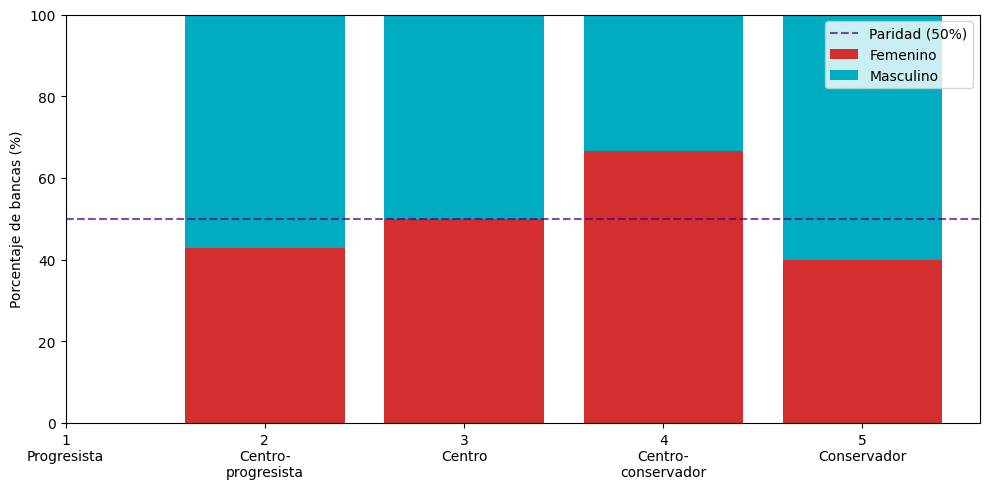

In [39]:
# 1. Calcular porcentajes por eje
resultado_sen_porc = resultado_sen_clasificados.copy()
totales_por_eje_sen = resultado_sen_porc.groupby('eje')['bancas'].transform('sum')
resultado_sen_porc['porcentaje'] = (resultado_sen_porc['bancas'] / totales_por_eje_sen) * 100

# 2. Pivotear
pivot_sen = resultado_sen_porc.pivot(index='eje', columns='genero', values='porcentaje').fillna(0)
pivot_sen = pivot_sen.reindex([1, 2, 3, 4, 5])

# 3. Graficar
fig, ax = plt.subplots(figsize=(10, 5))

# Barras apiladas
ax.bar(pivot_sen.index, pivot_sen['femenino'], label='Femenino', color='#D32F2F')
ax.bar(pivot_sen.index, pivot_sen['masculino'], bottom=pivot_sen['femenino'], label='Masculino', color='#00ACC1')

# Línea de paridad
ax.axhline(50, color='#4B0082', linestyle='--', alpha=0.7, label='Paridad (50%)')

# Etiquetas
ax.set_ylabel('Porcentaje de bancas (%)')
ax.legend()
ax.set_ylim(0, 100)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1\nProgresista', '2\nCentro-\nprogresista', '3\nCentro', '4\nCentro-\nconservador', '5\nConservador'])

plt.tight_layout()
plt.show()

#### COMPARACIÓN GÉNERO ENTRE CÁMARAS

Diputados: 257 bancas
   Mujeres: 106 (41.2%)
   Hombres: 151 (58.8%)

Senadores: 72 bancas
   Mujeres: 33 (45.8%)
   Hombres: 39 (54.2%)


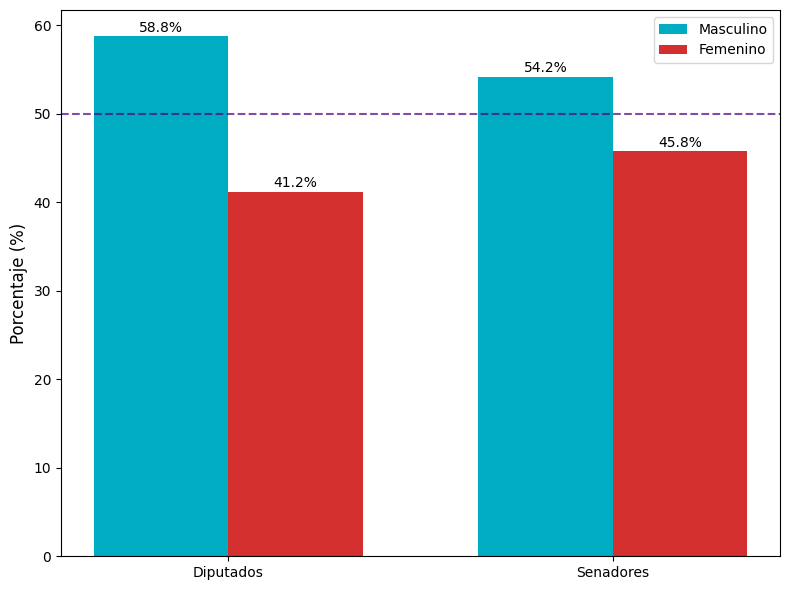

In [44]:
# Calcular porcentajes con tus datos actuales
total_diputados = len(diputados_actuales)
total_senadores = len(senadores_actuales)

mujeres_dip = len(diputados_actuales[diputados_actuales['genero'] == 'femenino'])
hombres_dip = len(diputados_actuales[diputados_actuales['genero'] == 'masculino'])

mujeres_sen = len(senadores_actuales[senadores_actuales['genero'] == 'femenino'])
hombres_sen = len(senadores_actuales[senadores_actuales['genero'] == 'masculino'])

hombres_pct = [round((hombres_dip / total_diputados) * 100, 1), 
               round((hombres_sen / total_senadores) * 100, 1)]
mujeres_pct = [round((mujeres_dip / total_diputados) * 100, 1), 
               round((mujeres_sen / total_senadores) * 100, 1)]


print(f"Diputados: {total_diputados} bancas")
print(f"   Mujeres: {mujeres_dip} ({mujeres_pct[0]}%)")
print(f"   Hombres: {hombres_dip} ({hombres_pct[0]}%)")
print(f"\nSenadores: {total_senadores} bancas")
print(f"   Mujeres: {mujeres_sen} ({mujeres_pct[1]}%)")
print(f"   Hombres: {hombres_sen} ({hombres_pct[1]}%)")

# Gráfico
camaras = ['Diputados', 'Senadores']
x = np.arange(len(camaras))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, hombres_pct, width, label='Masculino', color='#00ACC1')
bars2 = ax.bar(x + width/2, mujeres_pct, width, label='Femenino', color='#D32F2F')

ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(camaras)
ax.legend()
ax.axhline(50, color='#4B0082', linestyle='--', alpha=0.7, label='Paridad (50%)')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

#### ENCABEZAMIENTOS

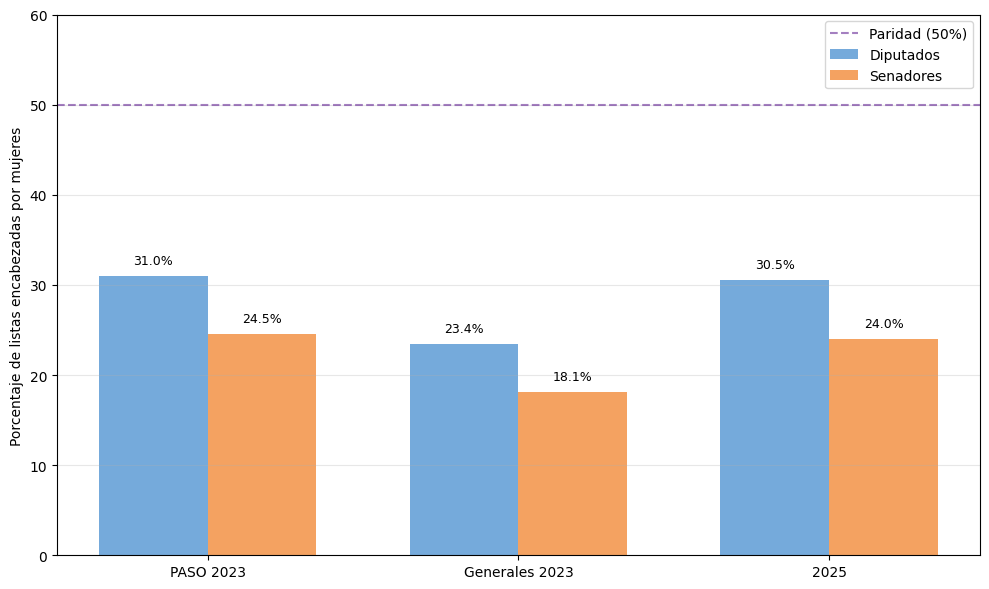

RESUMEN: % DE LISTAS ENCABEZADAS POR MUJERES SOBRE TOTAL DE LISTAS
      Elección    Cámara  Porcentaje
     PASO 2023 Diputados   30.961531
     PASO 2023 Senadores   24.516595
Generales 2023 Diputados   23.402778
Generales 2023 Senadores   18.125000
          2025 Diputados   30.501819
          2025 Senadores   24.017857


In [47]:
# VISUALIZACIÓN: % DE LISTAS ENCABEZADAS POR MUJERES SOBRE TOTAL DE LISTAS

# 1. Preparar datos para 2023 - PASO
paso_hcdn = E_23_PASO[E_23_PASO['camara'] == 'HCDN'].copy()
paso_hcdn['% mujeres sobre total'] = (paso_hcdn['listas encabezadas por mujeres'] / paso_hcdn['listas']) * 100
promedio_paso_hcdn = paso_hcdn['% mujeres sobre total'].mean()

paso_hsn = E_23_PASO[E_23_PASO['camara'] == 'HSN'].copy()
paso_hsn['% mujeres sobre total'] = (paso_hsn['listas encabezadas por mujeres'] / paso_hsn['listas']) * 100
promedio_paso_hsn = paso_hsn['% mujeres sobre total'].mean()

# 2. Preparar datos para 2023 - Generales
gen_hcdn = E_23_generales[E_23_generales['camara'] == 'HCDN'].copy()
gen_hcdn['% mujeres sobre total'] = (gen_hcdn['listas encabezadas por mujeres'] / gen_hcdn['listas']) * 100
promedio_generales_hcdn = gen_hcdn['% mujeres sobre total'].mean()

gen_hsn = E_23_generales[E_23_generales['camara'] == 'HSN'].copy()
gen_hsn['% mujeres sobre total'] = (gen_hsn['listas encabezadas por mujeres'] / gen_hsn['listas']) * 100
promedio_generales_hsn = gen_hsn['% mujeres sobre total'].mean()

# 3. Preparar datos para 2025
e25_dip = E_25_HCDN.copy()
e25_dip['% mujeres sobre total'] = (e25_dip['listas encabezadas por mujeres'] / e25_dip['listas']) * 100
promedio_2025_hcdn = e25_dip['% mujeres sobre total'].mean()

e25_sen = E_25_HSN.copy()
e25_sen['% mujeres sobre total'] = (e25_sen['listas encabezadas por mujeres'] / e25_sen['listas']) * 100
promedio_2025_hsn = e25_sen['% mujeres sobre total'].mean()

# 4. Crear DataFrame para graficar
datos = {
    'Elección': ['PASO 2023', 'PASO 2023', 'Generales 2023', 'Generales 2023', '2025', '2025'],
    'Cámara': ['Diputados', 'Senadores', 'Diputados', 'Senadores', 'Diputados', 'Senadores'],
    'Porcentaje': [
        promedio_paso_hcdn, promedio_paso_hsn,
        promedio_generales_hcdn, promedio_generales_hsn,
        promedio_2025_hcdn, promedio_2025_hsn
    ]
}

df_viz = pd.DataFrame(datos)

# 5. Graficar
fig, ax = plt.subplots(figsize=(10, 6))

colores = {'Diputados': '#75AADB', 'Senadores': '#F4A261'}

x = np.arange(len(df_viz['Elección'].unique()))
width = 0.35
offsets = {'Diputados': -width/2, 'Senadores': width/2}

for camara in ['Diputados', 'Senadores']:
    subset = df_viz[df_viz['Cámara'] == camara]
    x_pos = np.arange(len(subset)) + offsets[camara]
    ax.bar(x_pos, subset['Porcentaje'], width, label=camara, color=colores[camara])
    
    for i, (_, row) in enumerate(subset.iterrows()):
        ax.text(x_pos[i], row['Porcentaje'] + 1, f"{row['Porcentaje']:.1f}%", 
                ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Porcentaje de listas encabezadas por mujeres')
ax.set_xticks(np.arange(len(df_viz['Elección'].unique())))
ax.set_xticklabels(['PASO 2023', 'Generales 2023', '2025'])
ax.set_ylim(0, 60)
ax.axhline(50, color='#4B0082', linestyle='--', alpha=0.5, label='Paridad (50%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Tabla resumen
print("RESUMEN: % DE LISTAS ENCABEZADAS POR MUJERES SOBRE TOTAL DE LISTAS")
print(df_viz.to_string(index=False))

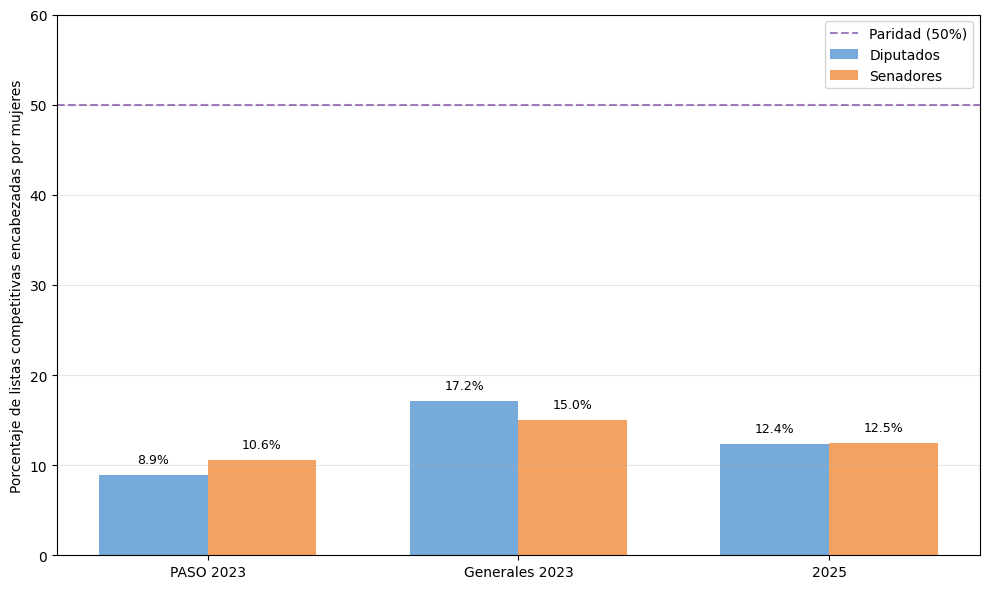

RESUMEN: % DE LISTAS COMPETITIVAS ENCABEZADAS POR MUJERES SOBRE TOTAL DE LISTAS
      Elección    Cámara  Porcentaje
     PASO 2023 Diputados    8.949866
     PASO 2023 Senadores   10.616883
Generales 2023 Diputados   17.152778
Generales 2023 Senadores   15.000000
          2025 Diputados   12.356978
          2025 Senadores   12.500000


In [49]:
# VISUALIZACIÓN: % DE LISTAS COMPETITIVAS ENCABEZADAS POR MUJERES SOBRE TOTAL DE LISTAS

# 1. Preparar datos para 2023 - PASO
# Calcular % = (listas competitivas encabezadas por mujeres / total de listas) * 100
paso_hcdn = E_23_PASO[E_23_PASO['camara'] == 'HCDN'].copy()
paso_hcdn['% competitivas mujeres sobre total'] = (paso_hcdn['listas competitivas encabezadas por mujeres'] / paso_hcdn['listas']) * 100
promedio_paso_hcdn = paso_hcdn['% competitivas mujeres sobre total'].mean()

paso_hsn = E_23_PASO[E_23_PASO['camara'] == 'HSN'].copy()
paso_hsn['% competitivas mujeres sobre total'] = (paso_hsn['listas competitivas encabezadas por mujeres'] / paso_hsn['listas']) * 100
promedio_paso_hsn = paso_hsn['% competitivas mujeres sobre total'].mean()

# 2. Preparar datos para 2023 - Generales
gen_hcdn = E_23_generales[E_23_generales['camara'] == 'HCDN'].copy()
gen_hcdn['% competitivas mujeres sobre total'] = (gen_hcdn['listas competitivas encabezadas por mujeres'] / gen_hcdn['listas']) * 100
promedio_generales_hcdn = gen_hcdn['% competitivas mujeres sobre total'].mean()

gen_hsn = E_23_generales[E_23_generales['camara'] == 'HSN'].copy()
gen_hsn['% competitivas mujeres sobre total'] = (gen_hsn['listas competitivas encabezadas por mujeres'] / gen_hsn['listas']) * 100
promedio_generales_hsn = gen_hsn['% competitivas mujeres sobre total'].mean()

# 3. Preparar datos para 2025 (cada cámara tiene su propio df)
e25_dip = E_25_HCDN.copy()
e25_dip['% competitivas mujeres sobre total'] = (e25_dip['listas competitivas encabezadas por mujeres'] / e25_dip['listas']) * 100
promedio_2025_hcdn = e25_dip['% competitivas mujeres sobre total'].mean()

e25_sen = E_25_HSN.copy()
e25_sen['% competitivas mujeres sobre total'] = (e25_sen['listas competitivas encabezadas por mujeres'] / e25_sen['listas']) * 100
promedio_2025_hsn = e25_sen['% competitivas mujeres sobre total'].mean()

# 4. Crear DataFrame para graficar
datos_competitivas = {
    'Elección': ['PASO 2023', 'PASO 2023', 'Generales 2023', 'Generales 2023', '2025', '2025'],
    'Cámara': ['Diputados', 'Senadores', 'Diputados', 'Senadores', 'Diputados', 'Senadores'],
    'Porcentaje': [
        promedio_paso_hcdn, promedio_paso_hsn,
        promedio_generales_hcdn, promedio_generales_hsn,
        promedio_2025_hcdn, promedio_2025_hsn
    ]
}

df_viz_competitivas = pd.DataFrame(datos_competitivas)

# 5. Graficar
fig, ax = plt.subplots(figsize=(10, 6))

colores = {'Diputados': '#75AADB', 'Senadores': '#F4A261'}

x = np.arange(len(df_viz_competitivas['Elección'].unique()))
width = 0.35
offsets = {'Diputados': -width/2, 'Senadores': width/2}

for camara in ['Diputados', 'Senadores']:
    subset = df_viz_competitivas[df_viz_competitivas['Cámara'] == camara]
    x_pos = np.arange(len(subset)) + offsets[camara]
    ax.bar(x_pos, subset['Porcentaje'], width, label=camara, color=colores[camara])
    
    for i, (_, row) in enumerate(subset.iterrows()):
        ax.text(x_pos[i], row['Porcentaje'] + 1, f"{row['Porcentaje']:.1f}%", 
                ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Porcentaje de listas competitivas encabezadas por mujeres')
ax.set_xticks(np.arange(len(df_viz_competitivas['Elección'].unique())))
ax.set_xticklabels(['PASO 2023', 'Generales 2023', '2025'])
ax.set_ylim(0, 60)
ax.axhline(50, color='#4B0082', linestyle='--', alpha=0.5, label='Paridad (50%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Tabla resumen
print("RESUMEN: % DE LISTAS COMPETITIVAS ENCABEZADAS POR MUJERES SOBRE TOTAL DE LISTAS")
print(df_viz_competitivas.to_string(index=False))

In [50]:
# PREPARAR DATOS: Unificar los tres momentos electorales

# Lista de columnas LCEM (ejes ideológicos)
columnas_eje = ['LCEM_Eje_1_Progresista', 'LCEM_Eje_2_Centro_Progresista', 'LCEM_Eje_3_Centro',
                'LCEM_Eje_4_Centro_Conservador', 'LCEM_Eje_5_Conservador']

# Nombres legibles para los ejes
nombres_ejes = {
    'LCEM_Eje_1_Progresista': 'Eje 1: Progresista',
    'LCEM_Eje_2_Centro_Progresista': 'Eje 2: Centroizquierda',
    'LCEM_Eje_3_Centro': 'Eje 3: Centro',
    'LCEM_Eje_4_Centro_Conservador': 'Eje 4: Centroderecha',
    'LCEM_Eje_5_Conservador': 'Eje 5: Conservador',
}

# Orden correcto de elecciones
orden_elecciones = ['PASO 2023', 'Generales 2023', '2025']

# 1. Procesar PASO 2023 (Diputados)
paso_dip = E_23_PASO[E_23_PASO['camara'] == 'HCDN'].copy()
paso_dip['eleccion'] = 'PASO 2023'
paso_dip['camara_nombre'] = 'Diputados'

# 2. Procesar PASO 2023 (Senadores)
paso_sen = E_23_PASO[E_23_PASO['camara'] == 'HSN'].copy()
paso_sen['eleccion'] = 'PASO 2023'
paso_sen['camara_nombre'] = 'Senadores'

# 3. Procesar Generales 2023 (Diputados)
gen_dip = E_23_generales[E_23_generales['camara'] == 'HCDN'].copy()
gen_dip['eleccion'] = 'Generales 2023'
gen_dip['camara_nombre'] = 'Diputados'

# 4. Procesar Generales 2023 (Senadores)
gen_sen = E_23_generales[E_23_generales['camara'] == 'HSN'].copy()
gen_sen['eleccion'] = 'Generales 2023'
gen_sen['camara_nombre'] = 'Senadores'

# 5. Procesar 2025 (Diputados)
e25_dip = E_25_HCDN.copy()
e25_dip['eleccion'] = '2025'
e25_dip['camara_nombre'] = 'Diputados'  # ← CORREGIDO

# 6. Procesar 2025 (Senadores)
e25_sen = E_25_HSN.copy()
e25_sen['eleccion'] = '2025'
e25_sen['camara_nombre'] = 'Senadores'  # ← CORREGIDO

# Unir todos los DataFrames
dfs_elecciones = [paso_dip, paso_sen, gen_dip, gen_sen, e25_dip, e25_sen]
df_total = pd.concat(dfs_elecciones, ignore_index=True)

# Añadir columna Centro si no existe
if 'LCEM_Eje_3_Centro' not in df_total.columns:
    df_total['LCEM_Eje_3_Centro'] = 0
    print(" Columna LCEM_Eje_3_Centro añadida con valores 0")

# Verificar que todo está bien
print(f"\n DataFrame total creado:")
print(f"   Filas: {len(df_total)}")
print(f"   Columnas: {df_total.columns.tolist()}")
print(f"   Cámaras: {df_total['camara_nombre'].unique()}")
print(f"   Elecciones: {df_total['eleccion'].unique()}")


 DataFrame total creado:
   Filas: 96
   Columnas: ['jurisdiccion', 'listas', 'listas encabezadas por mujeres', '% listas encabezadas por mujeres', 'listas competitivas', 'listas competitivas encabezadas por mujeres', '% listas competitivas encabezadas por mujeres', 'LCEM_Eje_1_Progresista', 'LCEM_Eje_2_Centro_Progresista', 'LCEM_Eje_4_Centro_Conservador', 'LCEM_Eje_5_Conservador', 'LCEM_Provincial', 'camara', 'LCEM_Eje_3_Centro', 'eleccion', 'camara_nombre']
   Cámaras: <StringArray>
['Diputados', 'Senadores']
Length: 2, dtype: str
   Elecciones: <StringArray>
['PASO 2023', 'Generales 2023', '2025']
Length: 3, dtype: str


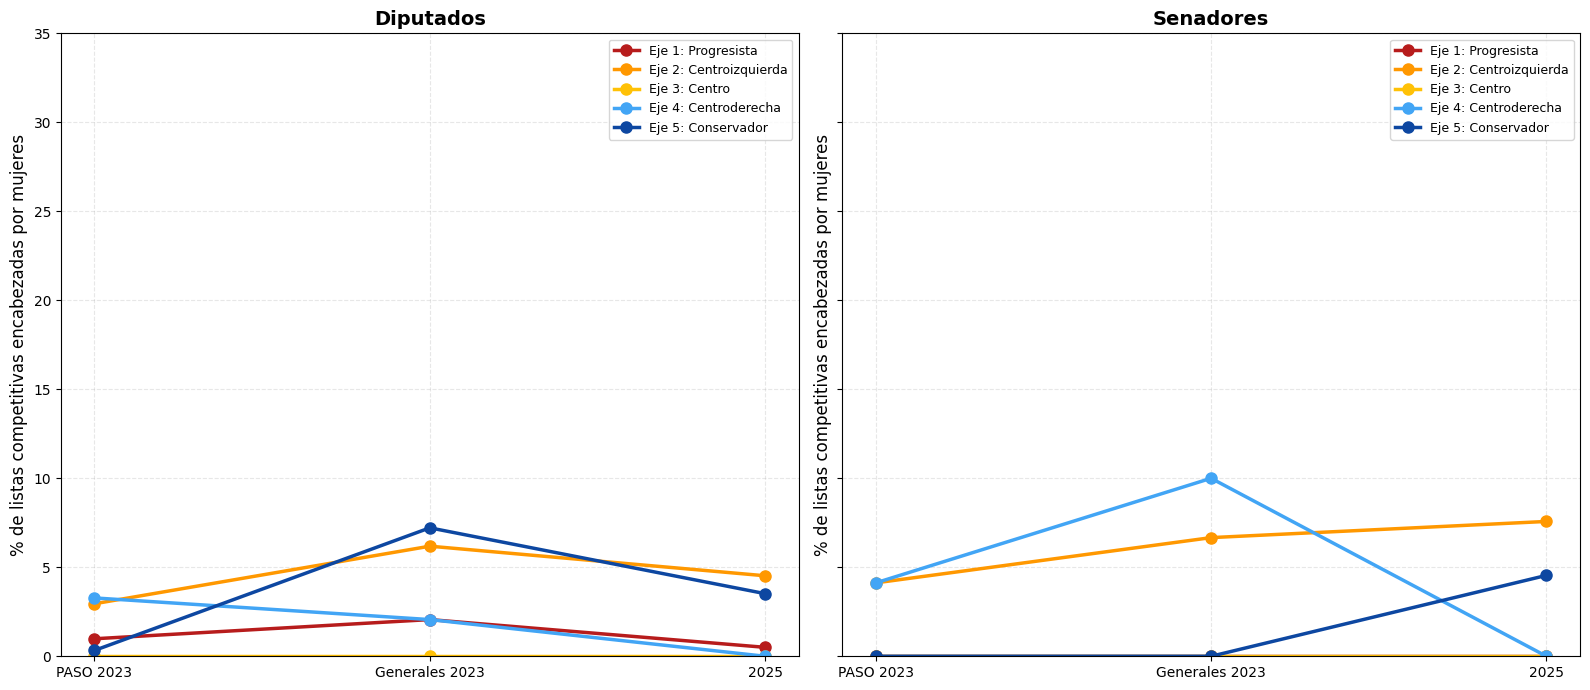

RESUMEN: % DE LISTAS COMPETITIVAS ENCABEZADAS POR MUJERES POR EJE IDEOLÓGICO
eje                       LCEM_Eje_1_Progresista  \
eleccion       camara                              
2025           Diputados                    0.50   
               Senadores                    0.00   
Generales 2023 Diputados                    2.06   
               Senadores                    0.00   
PASO 2023      Diputados                    0.98   
               Senadores                    0.00   

eje                       LCEM_Eje_2_Centro_Progresista  LCEM_Eje_3_Centro  \
eleccion       camara                                                        
2025           Diputados                           4.52                0.0   
               Senadores                           7.58                0.0   
Generales 2023 Diputados                           6.19                0.0   
               Senadores                           6.67                0.0   
PASO 2023      Diputados              

In [51]:
# GRÁFICO: % DE LISTAS COMPETITIVAS ENCABEZADAS POR MUJERES POR EJE IDEOLÓGICO

# 1. Primero, aseguramos la columna Eje 3 (Centro) con ceros en todos los df
for df in [E_23_PASO, E_23_generales, E_25_HCDN, E_25_HSN]:
    if 'LCEM_Eje_3_Centro' not in df.columns:
        df['LCEM_Eje_3_Centro'] = 0

# 2. Lista de columnas de ejes (excluyendo Provincial)
columnas_eje = [
    'LCEM_Eje_1_Progresista',
    'LCEM_Eje_2_Centro_Progresista',
    'LCEM_Eje_3_Centro',
    'LCEM_Eje_4_Centro_Conservador',
    'LCEM_Eje_5_Conservador'
]

# 3. Nombres legibles
nombres_ejes = {
    'LCEM_Eje_1_Progresista': 'Eje 1: Progresista',
    'LCEM_Eje_2_Centro_Progresista': 'Eje 2: Centroizquierda',
    'LCEM_Eje_3_Centro': 'Eje 3: Centro',
    'LCEM_Eje_4_Centro_Conservador': 'Eje 4: Centroderecha',
    'LCEM_Eje_5_Conservador': 'Eje 5: Conservador'
}

# 4. Orden de elecciones
orden_elecciones = ['PASO 2023', 'Generales 2023', '2025']

# 5. Procesar cada DataFrame para calcular porcentajes
# PASO 2023
paso_dip = E_23_PASO[E_23_PASO['camara'] == 'HCDN'].copy()
paso_dip['eleccion'] = 'PASO 2023'
paso_dip['camara_nombre'] = 'Diputados'

paso_sen = E_23_PASO[E_23_PASO['camara'] == 'HSN'].copy()
paso_sen['eleccion'] = 'PASO 2023'
paso_sen['camara_nombre'] = 'Senadores'

# Generales 2023
gen_dip = E_23_generales[E_23_generales['camara'] == 'HCDN'].copy()
gen_dip['eleccion'] = 'Generales 2023'
gen_dip['camara_nombre'] = 'Diputados'

gen_sen = E_23_generales[E_23_generales['camara'] == 'HSN'].copy()
gen_sen['eleccion'] = 'Generales 2023'
gen_sen['camara_nombre'] = 'Senadores'

# 2025 (no tienen columna 'camara')
e25_dip = E_25_HCDN.copy()
e25_dip['eleccion'] = '2025'
e25_dip['camara_nombre'] = 'Diputados'
# Asegurar columna Eje 4 si no existe
if 'LCEM_Eje_4_Centro_Conservador' not in e25_dip.columns:
    e25_dip['LCEM_Eje_4_Centro_Conservador'] = 0

e25_sen = E_25_HSN.copy()
e25_sen['eleccion'] = '2025'
e25_sen['camara_nombre'] = 'Senadores'
if 'LCEM_Eje_4_Centro_Conservador' not in e25_sen.columns:
    e25_sen['LCEM_Eje_4_Centro_Conservador'] = 0

# Unir todo
df_total = pd.concat([paso_dip, paso_sen, gen_dip, gen_sen, e25_dip, e25_sen], ignore_index=True)

# 6. Calcular porcentaje por jurisdicción y luego promediar
# Para cada combinación de elección, cámara y eje, calculamos:
# % = (listas competitivas encabezadas por mujeres en ese eje / total de listas) * 100

# Crear lista para almacenar resultados
resultados = []

for eleccion in orden_elecciones:
    for camara in ['Diputados', 'Senadores']:
        df_filtrado = df_total[(df_total['eleccion'] == eleccion) & (df_total['camara_nombre'] == camara)]
        
        for col in columnas_eje:
            # Suma de listas competitivas encabezadas por mujeres para este eje
            suma_eje = df_filtrado[col].sum()
            # Suma total de listas
            suma_total = df_filtrado['listas'].sum()
            
            if suma_total > 0:
                porcentaje = (suma_eje / suma_total) * 100
            else:
                porcentaje = 0
            
            resultados.append({
                'eleccion': eleccion,
                'camara': camara,
                'eje': col,
                'porcentaje': porcentaje
            })

df_porcentajes = pd.DataFrame(resultados)

# 7. Graficar
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

colores_eje = {
    'LCEM_Eje_1_Progresista': '#B71C1C',
    'LCEM_Eje_2_Centro_Progresista': '#FF9800',
    'LCEM_Eje_3_Centro': '#FFC107',
    'LCEM_Eje_4_Centro_Conservador': '#42A5F5',
    'LCEM_Eje_5_Conservador': '#0D47A1'
}

for idx, camara in enumerate(['Diputados', 'Senadores']):
    ax = axes[idx]
    df_camara = df_porcentajes[df_porcentajes['camara'] == camara]
    
    for col in columnas_eje:
        datos_eje = df_camara[df_camara['eje'] == col].set_index('eleccion').reindex(orden_elecciones)['porcentaje'].fillna(0)
        
        ax.plot(datos_eje.index, datos_eje.values, 
               marker='o', linewidth=2.5, markersize=8,
               label=nombres_ejes[col], color=colores_eje[col])
    
    ax.set_title(f'{camara}', fontsize=14, fontweight='bold')
    ax.set_ylabel('% de listas competitivas encabezadas por mujeres', fontsize=12)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 35)  # Ajustar según los valores reales

plt.tight_layout()
plt.show()

# 8. Tabla resumen
print("RESUMEN: % DE LISTAS COMPETITIVAS ENCABEZADAS POR MUJERES POR EJE IDEOLÓGICO")
print(df_porcentajes.pivot_table(index=['eleccion', 'camara'], columns='eje', values='porcentaje').fillna(0).round(2))

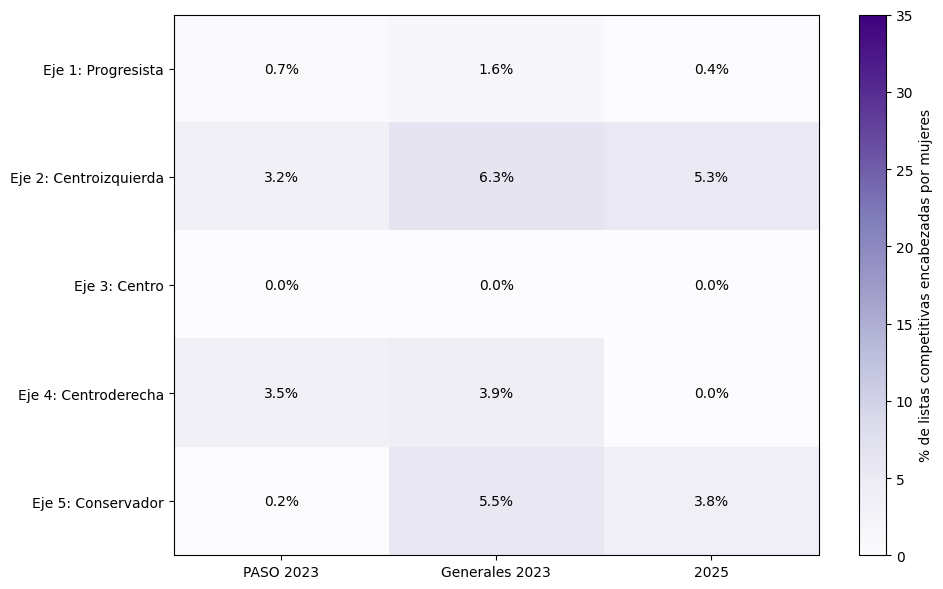

VERIFICACIÓN: % DE LISTAS COMPETITIVAS ENCABEZADAS POR MUJERES

Elección             Total listas    Eje 1: Progresi    Eje 2: Centroiz    Eje 3: Centro      Eje 4: Centrode    Eje 5: Conserva   
PASO 2023            402             0.75%               3.23%               0.00%               3.48%               0.25%              
Generales 2023       127             1.57%               6.30%               0.00%               3.94%               5.51%              
2025                 265             0.38%               5.28%               0.00%               0.00%               3.77%              


In [52]:
# GRÁFICO EXTRA: Mapa de calor - % de listas competitivas encabezadas por mujeres

# 1. Preparar datos combinando ambas cámaras
# Sumar listas totales por elección
total_listas_por_eleccion = df_total.groupby('eleccion')['listas'].sum().reindex(orden_elecciones)

# Sumar listas competitivas encabezadas por mujeres por eje y elección
df_heatmap_abs = df_total.groupby(['eleccion'])[columnas_eje].sum()
df_heatmap_abs = df_heatmap_abs.reindex(orden_elecciones).fillna(0)

# Calcular porcentaje: (listas por eje / total de listas) * 100
df_heatmap_pct = df_heatmap_abs.div(total_listas_por_eleccion, axis=0) * 100
df_heatmap_pct = df_heatmap_pct.fillna(0)

# Transponer para que los ejes sean filas y las elecciones columnas
df_heatmap_t = df_heatmap_pct.T

# 2. Graficar mapa de calor
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(df_heatmap_t.values, cmap='Purples', aspect='auto', vmin=0, vmax=35)

ax.set_xticks(np.arange(len(df_heatmap_t.columns)))
ax.set_yticks(np.arange(len(df_heatmap_t.index)))
ax.set_xticklabels(df_heatmap_t.columns)
ax.set_yticklabels([nombres_ejes[col] for col in df_heatmap_t.index])

# Añadir valores en cada celda (con 1 decimal)
for i in range(len(df_heatmap_t.index)):
    for j in range(len(df_heatmap_t.columns)):
        valor = df_heatmap_t.iloc[i, j]
        text = ax.text(j, i, f"{valor:.1f}%",
                       ha="center", va="center", color="black" if valor < 20 else "white", fontsize=10)

plt.colorbar(im, ax=ax, label='% de listas competitivas encabezadas por mujeres')

plt.tight_layout()
plt.show()

# 3. Tabla de verificación
print("VERIFICACIÓN: % DE LISTAS COMPETITIVAS ENCABEZADAS POR MUJERES")
print(f"\n{'Elección':<20} {'Total listas':<15}", end="")
for eje in columnas_eje:
    print(f" {nombres_ejes[eje][:15]:<18}", end="")
print()

for eleccion in orden_elecciones:
    total = total_listas_por_eleccion[eleccion]
    print(f"{eleccion:<20} {int(total):<15}", end="")
    for eje in columnas_eje:
        pct = df_heatmap_pct.loc[eleccion, eje]
        print(f" {pct:.2f}%{' ':<14}", end="")
    print()